In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np

In [2]:
def plot(ax, filename, maxd, maxp, normalise=False, normalise_energies=True, show_cbar=False):
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/param_exploration/LR_equal.{filename}.d{maxd}.p{maxp}.normalise{normalise}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    deltas = res['delta_bs'] if 'delta_bs' in res.keys() else res['deltas']
    ps = res['ps']
    energies = np.array(energies)
    if normalise_energies:
        energies /= energies.max()
        # energies /= energies[0,0]
        norm = colors.Normalize(vmin=0.5, vmax=1)
    else:
        norm=None
    im = ax.pcolormesh(ps, deltas, energies.T, shading='nearest', norm=norm)
    
    if show_cbar:
        cbar = ax.figure.colorbar(im, ax=ax)
        label = '$\\frac{H_C}{\\max(H_C)}$' if normalise_energies else '${H_C}$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=25 if normalise_energies else 10)
    ax.set_xlabel('p')
    ax.set_ylabel(r'$\Delta_\beta = \Delta_\gamma$')
    return ax

In [3]:
# fig, axs = plt.subplots(2, 3)
# ax0 = plot(axs[0, 0], 'test_N2_W2', '3.14', '30', False, False, True)
# ax1 = plot(axs[0, 1],'trivial', '3.14', '30', False, False, True)
# ax2 = plot(axs[0, 2],'test_N3_W4', '3.14', '30', False, False, True)
# ax3 = plot(axs[1, 0], 'test_N3_W5', '3.14', '30', False, False, True)
# ax5 = plot(axs[1, 1],'test_N4_W5', '3.14', '30', False, False, True)
# # ax4 = plot(axs[1, 2],'test_N7_W4', '3.14', '50', False, True, True)
# fig.set_figheight(10)
# fig.set_figwidth(18)

In [4]:
# fig, axs = plt.subplots(2, 3)
# ax0 = plot(axs[0, 0], 'test_N2_W2', '1.0', '30', False, False, True)
# ax1 = plot(axs[0, 1],'trivial', '1.0', '30', False, False, True)
# ax2 = plot(axs[0, 2],'test_N3_W4', '1.0', '30', False, False, True)
# ax3 = plot(axs[1, 0], 'test_N3_W5', '1.0', '30', False, False, True)
# ax5 = plot(axs[1, 1],'test_N4_W5', '1.0', '30', False, False, True)
# # ax4 = plot(axs[1, 2],'test_N7_W4', '3.14', '50', False, True, True)

# fig.set_figheight(10)
# fig.set_figwidth(18)

In [5]:
def plot_3d(axs, filename, maxdb, maxdg, maxp, normalise=True):
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/param_exploration/LR_unequal.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    energies = np.array(energies)
    print(np.min(np.min(energies, axis=1), axis=1))
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]

    norm = colors.Normalize(vmin=np.min(energies), vmax=np.max(energies))

    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))]    
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(delta_bs, delta_gs, energies[plot_ps[i],:,:].T, shading='nearest', norm=norm)
        ax.set_xlabel(r'$\Delta_\beta$')
        ax.set_ylabel(r'$\Delta_\gamma$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$\frac{H_C}{\max(H_C)}$' if normalise else '$H_C$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=25 if normalise else 10)
    return axs

In [6]:
# fig, axs = plt.subplots(6, 5)
# plot_3d(axs[0, :], 'test_N2_W2', '3.14', '6.28', '21', False)
# plot_3d(axs[1, :], 'trivial', '3.14', '6.28', '21', False)
# plot_3d(axs[2, :], 'test_N3_W4', '3.14', '6.28', '21', False)
# plot_3d(axs[3, :], 'test_N3_W5', '3.14', '6.28', '21', False)
# plot_3d(axs[4, :], 'test_N4_W5', '3.14', '6.28', '21', False)
# plot_3d(axs[5, :], 'test_N7_W4', '3.14', '6.28', '21', False)


# fig.set_figheight(3 * len(axs[:,0]))
# fig.set_figwidth(3 * len(axs[0,:]))
# plt.tight_layout()

In [7]:
# fig, axs = plt.subplots(2, 5)
# db = 0.1
# dg = 0.2
# maxp = 21
# plot_3d(axs[0, :], 'test_N2_W2', db, dg, maxp, False)
# plot_3d(axs[1, :], 'trivial', db, dg, maxp, False)
# # plot_3d(axs[2, :], 'test_N3_W4', db, dg, maxp, False)
# # plot_3d(axs[3, :], 'test_N3_W5', db, dg, maxp, False)
# # plot_3d(axs[4, :], 'test_N4_W5', db, dg, maxp, False)
# # plot_3d(axs[5, :], 'test_N7_W4', db, dg, maxp, False)


# fig.set_figheight(3 * len(axs[:,0]))
# fig.set_figwidth(3 * len(axs[0,:]))
# plt.tight_layout()

In [8]:
x = np.random.random((3,3))
print(x)
np.unravel_index(np.argmax(x), x.shape)

[[0.01432836 0.60133528 0.9973811 ]
 [0.81554587 0.08450931 0.83249976]
 [0.79048879 0.21783757 0.75943235]]


(np.int64(0), np.int64(2))

In [9]:
def plot_p_opt_3d(axs, filename, maxdb, maxdg, maxp):
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/param_exploration/LR_unequal.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    p_opts = res['p_opts']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    p_opts = np.array(p_opts)
    print(np.max(np.max(p_opts, axis=1), axis=1))

    norm = colors.Normalize(vmin=0, vmax=np.max(p_opts))
    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))] 
    
    print(
        [
            (
                round(delta_bs[np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)[0]],2), 
                round(delta_gs[np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)[1]],2)
            ) 
            for i in range(len(axs)) 
        ]
    ) 
    
      
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(np.log10(delta_bs), np.log10(delta_gs), p_opts[plot_ps[i],:,:].T, shading='nearest', norm=norm)
        ix, iy = np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)
        x_max = np.log10(delta_bs)[ix]
        y_max = np.log10(delta_gs)[iy]
        ax.plot(
            x_max, y_max,
            marker='x',
            color='red',
            markersize=8,
            # markeredgecolor='white',
            zorder=10
        )
        ax.set_xlabel(r'$\log(\Delta_\beta)$')
        ax.set_ylabel(r'$\log(\Delta_\gamma)$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$p_{\text{opt}}$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=10)
    return axs

[0.52913598 0.76327121 0.94690437 0.99965636 0.99999922 1.00000364]
[(np.float64(0.94), np.float64(0.43)), (np.float64(1.53), np.float64(0.89)), (np.float64(0.74), np.float64(0.34)), (np.float64(0.58), np.float64(0.34)), (np.float64(0.58), np.float64(0.26)), (np.float64(0.58), np.float64(0.21))]
[0.06750723 0.18419881 0.26519775 0.66290947 0.97159793 0.99996141]
[(np.float64(0.74), np.float64(1.44)), (np.float64(0.58), np.float64(1.44)), (np.float64(0.58), np.float64(0.43)), (np.float64(0.45), np.float64(0.43)), (np.float64(0.45), np.float64(0.34)), (np.float64(0.36), np.float64(0.34))]
[0.04944197 0.09484002 0.23028516 0.53993385 0.9041886  0.99850569]
[(np.float64(0.74), np.float64(0.34)), (np.float64(0.58), np.float64(1.44)), (np.float64(0.58), np.float64(0.26)), (np.float64(0.58), np.float64(0.26)), (np.float64(0.58), np.float64(0.26)), (np.float64(0.58), np.float64(0.21))]
[0.01544874 0.0380654  0.069968   0.29323083 0.65324136 0.9542699 ]
[(np.float64(0.94), np.float64(7.85)), (n

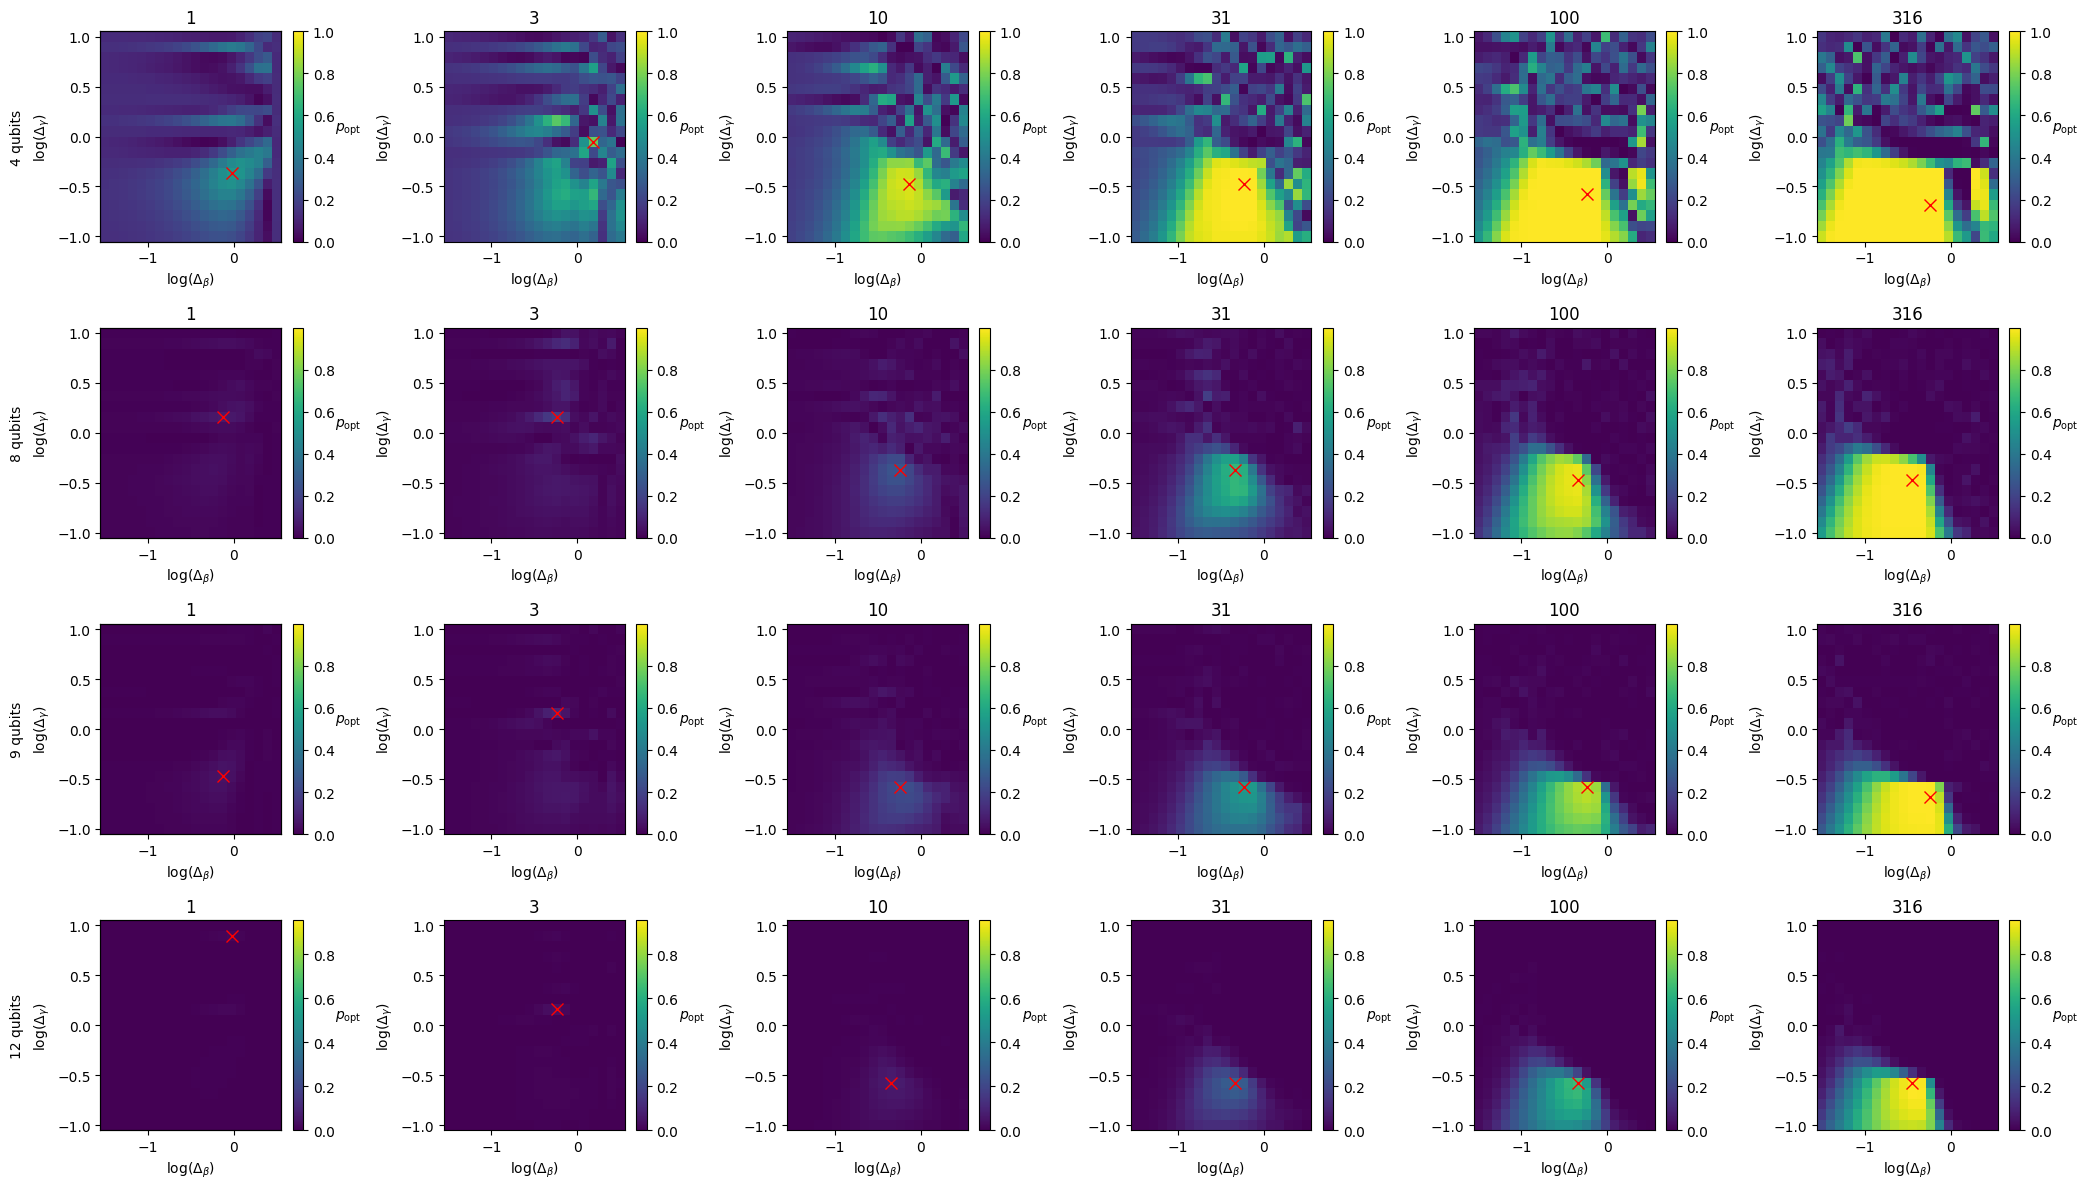

In [10]:
fig, axs = plt.subplots(4, 6)
db = 3.16
dg = 10.0
maxp = 316

qubits = [4, 8, 9, 12]
plot_p_opt_3d(axs[0, :], 'test_N2_W2', db, dg, maxp)
plot_p_opt_3d(axs[1, :], 'test_N7_W2', db, dg, maxp)
plot_p_opt_3d(axs[2, :], 'trivial', db, dg, maxp)
plot_p_opt_3d(axs[3, :], 'test_N8_W3', db, dg, maxp)


for idx, ax in enumerate(axs[:, 0]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    twin.yaxis.set_label_coords(-0.5,0.5)

fig.set_figheight(3 * len(axs[:,0]))
fig.set_figwidth(3.5 * len(axs[0,:]))
plt.tight_layout()

[0.01170474 0.01880499 0.10527217 0.24802837 0.44908734 0.78227128]
[(np.float64(0.79), np.float64(0.32)), (np.float64(1.0), np.float64(0.2)), (np.float64(0.63), np.float64(0.22)), (np.float64(0.5), np.float64(0.22)), (np.float64(0.5), np.float64(0.22)), (np.float64(0.5), np.float64(0.2))]
[0.00354456 0.00662612 0.05636655 0.20512828 0.49282797 0.85370369]
[(np.float64(0.79), np.float64(0.32)), (np.float64(0.5), np.float64(0.32)), (np.float64(0.5), np.float64(0.28)), (np.float64(0.63), np.float64(0.2)), (np.float64(0.63), np.float64(0.2)), (np.float64(0.5), np.float64(0.2))]


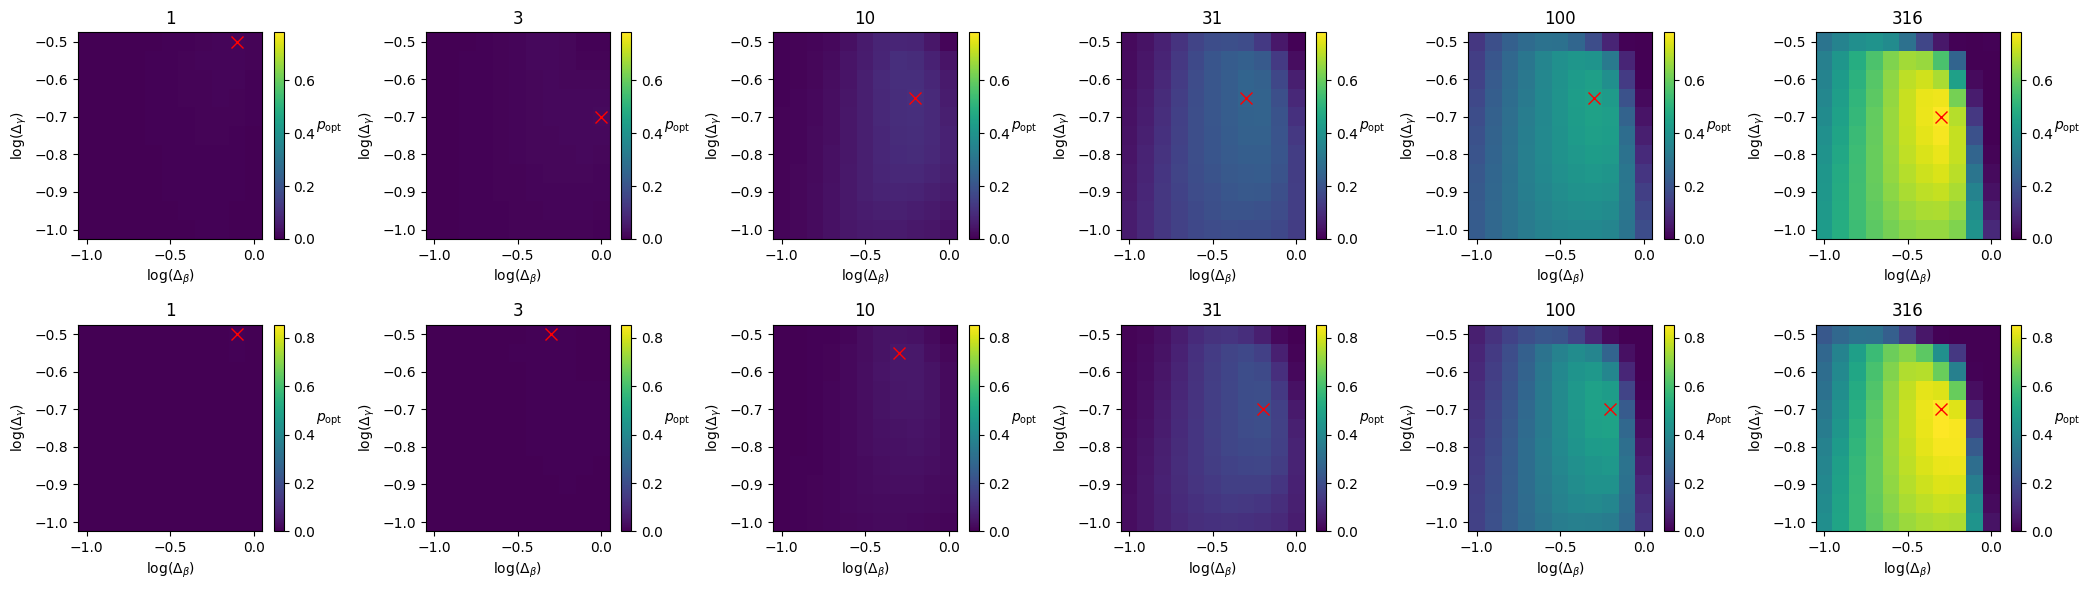

In [14]:
fig, axs = plt.subplots(2, 6)
db = 1.0
dg = 0.32
maxp = 316
plot_p_opt_3d(axs[0, :], 'test_N3_W4', db, dg, maxp)
plot_p_opt_3d(axs[1, :], 'test_N4_W5', db, dg, maxp)
# plot_p_opt_3d(axs[2, :], 'test_N7_W2', db, dg, maxp)



fig.set_figheight(3 * len(axs[:,0]))
fig.set_figwidth(3.5 * len(axs[0,:]))
plt.tight_layout()